In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.dates as mdates
import numpy as np

import intake

import sys
sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/") 
sys.path.append("/work/mh1498/m301248/TCO_data/BCO_observational/mass_fluxes_profiles/yk22_mass_fluxes.py")

import metpy

import meteo

import esmtools


import pandas as pd
from IPython.display import display, HTML

/work/mh1498/m301248/conda/envs/env_hacka/lib/python3.12/site-packages/esmtools/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
## what is the reference layer to compute mixed layer AVERAGED quantities?
mixed_avg_levels   = slice(200, 400)

Rd = 287.
cp = 1004. # j / kg K
Lv = 2.5e6 # J/kg
g = 9.81   # m/s2


Fa_q_eu, Fa_q_or    = (-2e-3)/86400. , (-0.e-3)/86400.   # kg/kg / day
Fa_th_eu , Fa_th_or = -0.75/86400.,       -0./86400.        # K/day
bl_height        = 500.                                    #  mean mixed layer height / m
bl_density       = 1. 


## test what happens with fractions of

In [4]:
min_hgt = 40.

level2_path = "/work/mh1498/m301248/TCO_data/eurec4a_profiles_level2/EUREC4A_BCO_Vaisala-RS_L2_v3.0.0.nc"
ds_eureca = xr.open_dataset(level2_path)
ds_eureca_bco = ds_eureca.where(((ds_eureca["platform"] == 1)&(ds_eureca["ascent_flag"]==1)&(ds_eureca.alt>min_hgt)), drop=True)
## renaming for common ground
ds_eureca_bco = ds_eureca_bco.swap_dims({"sounding": "launch_time"})
ds_eureca_bco = ds_eureca_bco.rename({"alt":"height"})

## select time period with constant spacing
time_eu = slice("2020-01-21", "2020-02-17")
ds_eureca_bco = ds_eureca_bco.sel(launch_time=time_eu)


ds_orcestra = xr.open_dataset("ipfs://bafybeid7cnw62zmzfgxcvc6q6fa267a7ivk2wcchbmkoyk4kdi5z2yj2w4", engine="zarr")
ds_orcestra
ds_orcestra_bco = ds_orcestra.where(((ds_orcestra["platform"] == "BCO")&(ds_orcestra["ascent_flag"]==0)&(ds_orcestra.height>min_hgt)), drop=True)

## select time period with pretty much constant spacing
time_or = slice("2024-09-13", "2024-09-28")
ds_orcestra_bco = ds_orcestra_bco.sel(launch_time=time_or)


[3.9816075  3.99821667 4.05874806 3.97071776 3.9152639  4.03682224
 4.00513053 3.91564611 4.07713169 4.16791943 3.80743417 4.03418251
 3.99313693 4.01117029 4.46898721 3.63693889 3.80273888 4.08302947
 4.00862054 3.9464989 ]
[3.24047334 5.80486666 3.01612308 2.98807777 6.05443056 2.9593297
 3.05340168 2.92320109 3.07614612 3.15818253 2.79736025 3.05175555
 2.98230923 2.94057137 2.98493497 6.01075277 3.02364637 2.99663138
 5.99708725 0.38208332]


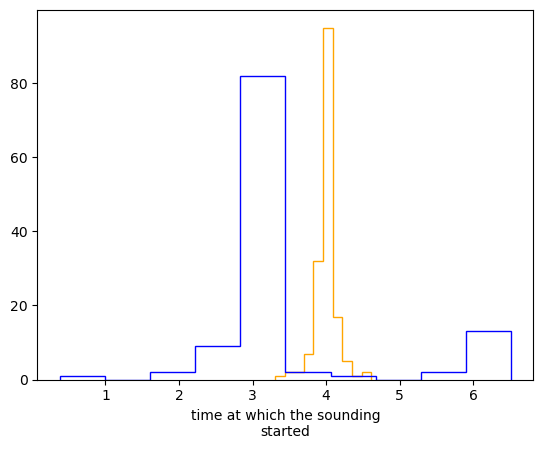

In [5]:
lag_eu = ds_eureca_bco.launch_time.diff(dim="launch_time")
(lag_eu / np.timedelta64(1, "h")).plot.hist(histtype="step", color="orange")

print(lag_eu.values[0:20]/ np.timedelta64(1, "h"))

lag_or = ds_orcestra_bco.launch_time.diff(dim="launch_time")
(lag_or / np.timedelta64(1, "h")).plot.hist(histtype="step", color="blue")

print(lag_or.values[0:20]/ np.timedelta64(1, "h"))


plt.show()



In [6]:
# ds is an xarray.Dataset or DataArray
acf_qEu = esmtools.stats.autocorr(ds_eureca_bco.q.sel(height=mixed_avg_levels).mean(dim="height"), dim='launch_time', nlags=20)
acf_qOr = esmtools.stats.autocorr(ds_orcestra_bco.q.sel(height=mixed_avg_levels).mean(dim="height"), dim='launch_time', nlags=20)

acf_thEu = esmtools.stats.autocorr(ds_eureca_bco.theta.sel(height=mixed_avg_levels).mean(dim="height"), dim='launch_time', nlags=20)
acf_thOr = esmtools.stats.autocorr(ds_orcestra_bco.theta.sel(height=mixed_avg_levels).mean(dim="height"), dim='launch_time', nlags=20)


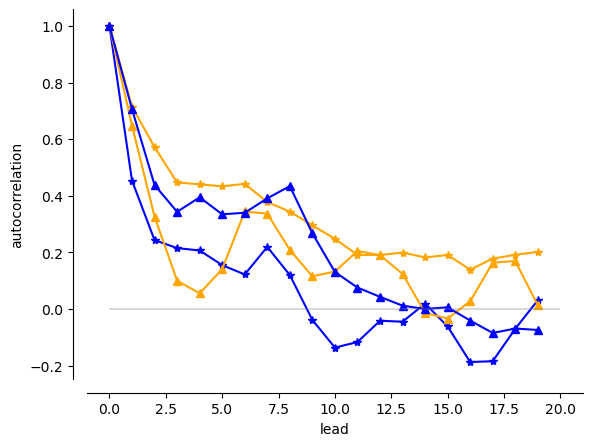

In [7]:
acf_qEu.plot(color="orange", marker="*")
acf_qOr.plot(color="blue", marker="*")

acf_thEu.plot(color="orange", marker="^")
acf_thOr.plot(color="blue", marker="^")


plt.gca().set_ylabel("autocorrelation")

plt.gca().spines["left"].set_position(("outward", 10))
plt.gca().spines["bottom"].set_position(("outward", 10))
plt.gca().hlines(0, xmin=0, xmax=20, color="grey", alpha=0.3)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

In [8]:
import xarray as xr
import numpy as np

def lagged_autocorr(data, lags):
    """
    Compute autocorrelation for a list of lags.
    data: xarray DataArray
    lags: list of integers
    """
    results = {}
    for lag in lags:
        if lag == 0:
            results[lag] = 1.0
        else:
            # Shift the data and compute correlation
            shifted_data = data.shift(launch_time=lag)
            # Align to handle NaNs introduced by shift
            valid_mask = data.notnull() & shifted_data.notnull()
            if valid_mask.sum() > 0:
                # Compute Pearson correlation on valid data
                # Note: xarray.corr computes pairwise correlation
                corr = xr.corr(
                data.where(valid_mask),
                shifted_data.where(valid_mask),
                dim="launch_time",  # or whatever your time dimension is called
                )
                results[lag] = corr
            else:
                results[lag] = np.nan
    return results   

In [9]:
lags = list(np.linspace(1,20, dtype=int))

ac_qEu = lagged_autocorr(ds_eureca_bco.q.sel(height=mixed_avg_levels).mean(dim="height"), lags=lags)
ac_thEu = lagged_autocorr(ds_eureca_bco.theta.sel(height=mixed_avg_levels).mean(dim="height"), lags=lags)

ac_qOr = lagged_autocorr(ds_orcestra_bco.q.sel(height=mixed_avg_levels).mean(dim="height"), lags=lags)
ac_thOr = lagged_autocorr(ds_orcestra_bco.theta.sel(height=mixed_avg_levels).mean(dim="height"), lags=lags)

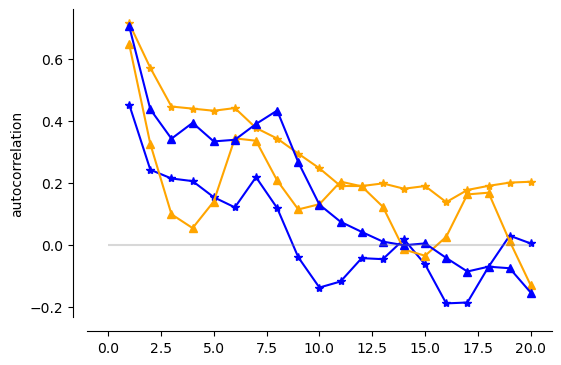

In [10]:
plt.figure(figsize=(6, 4))


lags = np.array(list(ac_qEu.keys()))
acf = np.array([
    ac_qEu[lag].item() if hasattr(ac_qEu[lag], "item") else ac_qEu[lag]
    for lag in lags
])
plt.plot(lags, acf, marker="*", color="orange")


acf = np.array([
    ac_qOr[lag].item() if hasattr(ac_qOr[lag], "item") else ac_qOr[lag]
    for lag in lags
])
plt.plot(lags, acf, marker="*", color="blue")


acf = np.array([
    ac_thEu[lag].item() if hasattr(ac_thEu[lag], "item") else ac_thEu[lag]
    for lag in lags
])
plt.plot(lags, acf, marker="^", color="orange")


acf = np.array([
    ac_thOr[lag].item() if hasattr(ac_thOr[lag], "item") else ac_thOr[lag]
    for lag in lags
])
plt.plot(lags, acf, marker="^", color="blue")


plt.gca().set_ylabel("autocorrelation")

plt.gca().spines["left"].set_position(("outward", 10))
plt.gca().spines["bottom"].set_position(("outward", 10))
plt.gca().hlines(0, xmin=0, xmax=20, color="grey", alpha=0.3)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)


the soundings in ORCESTRA are not uniformly spaced in time!!! I can try use data from the BCO WXT

In [11]:
cat = intake.open_catalog("https://tcodata.mpimet.mpg.de/catalog.yaml")
wxt = cat.BCO.wxt.to_dask()

In [12]:
vel  = wxt['VEL']
temp = wxt['T'] + 273.15  ## deg K
rh   = wxt['RH']/100.     ## values betwen 0 and 1

sfc_pressure = wxt['P']   ## already in hPa
from functions_collector import mr_from_rh

# temp is already in Kelvin
# press is already in mb
# rh was converted between 0 nd 1
q = mr_from_rh(temp, sfc_pressure, rh)


temp, rh, q, vel = xr.align(temp, rh, q, vel, join="inner")

valid_mask = temp.notnull() & rh.notnull() & q.notnull() & vel.notnull()

vel  =  xr.where(valid_mask,  vel , np.nan)  
temp =  xr.where(valid_mask, temp , np.nan)       
rh   =  xr.where(valid_mask, rh , np.nan)       
q    =  xr.where(valid_mask,  q,   np.nan)    




In [13]:
## SELECT CONTINUOUS TIME SERIES OF Non-Nans

import pandas as pd
from scipy.ndimage import gaussian_filter1d
from functions_collector import gaussian_filter_nan



mask = temp.notnull()
mask = mask.to_pandas()

# ---- this ensures the mask is 1D
if isinstance(mask, pd.DataFrame):
    mask = mask.squeeze()

# ---- Step 2: Identify contiguous groups
group_id = (mask != mask.shift()).cumsum()

cleanSeries = []
for g, group in mask.groupby(group_id):
    if group.iloc[0]:  # True segment
        start = group.index[0]
        end = group.index[-1]
        duration = end - start
        duration_hr = pd.Timedelta(duration) / pd.Timedelta(hours=1)
        event_wind = temp.sel(time=slice(start, end))
        cleanSeries.append({"start": start,\
                       "end": end, \
                       "duration_hr": duration_hr, \
                       }
                           )


cleanSeries_df = pd.DataFrame(cleanSeries).sort_values(by="duration_hr", ascending=False).reset_index(drop=True)
cleanSeries_df


,start,end,duration_hr
0,2016-09-19 07:17:00,2021-04-11 04:19:10,39957.036111
1,2023-05-06 19:00:40,2026-08-05 23:59:50,28492.986111
2,2012-11-14 20:50:50,2015-06-19 10:08:20,22717.291667
3,2010-12-16 16:24:00,2012-11-14 20:50:30,16780.441667
4,2021-04-11 05:30:50,2022-11-22 07:01:40,14161.513889
...,...,...,...
2402,2022-11-22 10:49:40,2022-11-22 10:49:40,0.000000
2403,2022-11-22 10:50:10,2022-11-22 10:50:10,0.000000
2404,2023-04-24 16:35:10,2023-04-24 16:35:10,0.000000
2405,2022-11-22 10:47:20,2022-11-22 10:47:20,0.000000


In [17]:
temp_eu = temp.sel(time=time_eu).resample(time="1h").mean().compute()
temp_or = temp.sel(time=time_or).resample(time="1h").mean().compute()

q_eu = q.sel(time=time_eu).resample(time="1h").mean().compute()
q_or = q.sel(time=time_or).resample(time="1h").mean().compute()

u_eu = vel.sel(time=time_eu).resample(time="1h").mean().compute()
u_or = vel.sel(time=time_or).resample(time="1h").mean().compute()

In [18]:
# ds is an xarray.Dataset or DataArray
acf_thEu = esmtools.stats.autocorr(temp_eu, dim='time', nlags=60)
acf_thOr = esmtools.stats.autocorr(temp_or, dim='time', nlags=60)

acf_qEu = esmtools.stats.autocorr(q_eu, dim='time', nlags=60)
acf_qOr = esmtools.stats.autocorr(q_or, dim='time', nlags=60)

acf_UEu = esmtools.stats.autocorr(u_eu, dim='time', nlags=60)
acf_UOr = esmtools.stats.autocorr(u_or, dim='time', nlags=60)

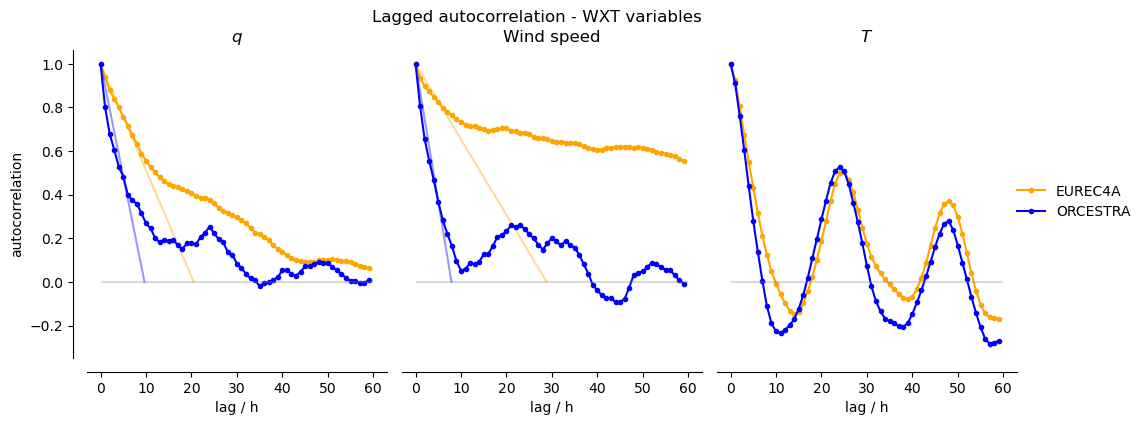

In [28]:
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(12, 4), sharex=True, sharey=True,
    gridspec_kw={"wspace": 0.05}
)
fig.suptitle("Lagged autocorrelation - WXT variables")

# Left panel: q
acf_qEu.plot(ax=ax1, color="orange", marker=".")
m = (1 - acf_qEu.values[5]) / (-5)
x = np.linspace(0,-1/m, 10)
ax1.plot(x, m*x+1, color="orange", alpha=0.4)


acf_qOr.plot(ax=ax1, color="blue", marker=".")
m = (1 - acf_qOr.values[5]) / (-5)
x = np.linspace(0,-1/m, 10)
ax1.plot(x, m*x+1, color="blue", alpha=0.4)

ax1.set_title(r"$q$")
ax1.set_xlabel("lag / h")
ax1.set_ylabel("autocorrelation")
# ax1.set_ylim(-0.01,1)

ax1.spines["left"].set_position(("outward", 10))
ax1.spines["bottom"].set_position(("outward", 10))

for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)



# centre panel: U
acf_UEu.plot(ax=ax2, color="orange", marker=".")
m = (1 - acf_UEu.values[5]) / (-5)
x = np.linspace(0,-1/m, 10)
ax2.plot(x, m*x+1, color="orange", alpha=0.4)

acf_UOr.plot(ax=ax2, color="blue", marker=".")
m = (1 - acf_UOr.values[5]) / (-5)
x = np.linspace(0,-1/m, 10)
ax2.plot(x, m*x+1, color="blue", alpha=0.4)

ax2.set_title(r"Wind speed")
ax2.set_xlabel("lag / h")

ax2.spines["bottom"].set_position(("outward", 10))
ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)

# Hide the y-axis completely
ax2.yaxis.set_visible(False)



# right panel: theta
acf_thEu.plot(ax=ax3, color="orange", marker=".")
acf_thOr.plot(ax=ax3, color="blue", marker=".")

ax3.set_title(r"$T$")
ax3.set_xlabel("lag / h")

ax3.spines["bottom"].set_position(("outward", 10))
ax3.spines["left"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.spines["top"].set_visible(False)

# Hide the y-axis completely
ax3.yaxis.set_visible(False)




for x in (ax1, ax2, ax3):
    x.hlines(0, xmin=0, xmax=60, color="grey", alpha=0.3)



from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color="orange", marker=".", linestyle="-", label="EUREC4A"),
    Line2D([0], [0], color="blue", marker=".", linestyle="-", label="ORCESTRA"),
]

fig.legend(
    handles=legend_handles,
    loc="center right",      # or "upper center"
    bbox_to_anchor=(1.005, 0.5),
    frameon=False,
)


plt.show()